In [3]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 1. SETUP PARAMETER DASAR (Uang Saku Rp2.000.000, Tinggal Bersama Ortu)
start_date = datetime(2026, 1, 1)
end_date = datetime(2026, 6, 30)
date_range = [start_date + timedelta(days=x) for x in range((end_date - start_date).days + 1)]

monthly_income = 2000000
data_rows = []

# Target Pengeluaran Total Bulanan (Mengunci grafik ideal sebelumnya)
monthly_targets = {
    '2026-01': 1600000, '2026-02': 1550000, '2026-03': 1650000,
    '2026-04': 2300000, '2026-05': 1200000, '2026-06': 1150000
}

# Template Transaksi disesuaikan: Lebih berfokus pada Makanan & Transportasi Kuliah
templates = {
    'Needs': {
        'Food & Dining': ['Makan siang di kantin kampus', 'Nasi Padang lauk ayam', 'Makan malam Warteg', 'Sarapan bubur ayam komplek'],
        'Transportation': ['Isi bensin Pertalite motor', 'Top up e-money Commuter Line', 'Gojek ke stasiun'],
        'Groceries': ['Beli cemilan & air mineral', 'Kebutuhan harian Alfamart'],
        'Bills & Utilities': ['Isi pulsa paket data internet', 'Top up saldo e-wallet harian'],
        'Education': ['Fotokopi tugas kuliah', 'Iuran kas angkatan', 'Print laporan praktikum']
    },
    'Wants': {
        'Food & Dining': ['Nongkrong di Coffee Shop', 'Beli Kopi Susu Kekinian', 'Jajan Mixue bareng teman', 'Makan Shihlin / McD'],
        'Shopping': ['Beli kaos polos Shopee', 'Checkout barang di Tokopedia', 'Beli aksesoris gadget'],
        'Entertainment': ['Tiket nonton bioskop XXI', 'Top up voucher game', 'Langganan Spotify Premium'],
        'Others': ['Bayar parkir mall/kampus', 'Patungan kado teman wisuda']
    }
}

# 2. PROSES GENERATION
# Masukkan Income di setiap tanggal 1
for date in date_range:
    month_str = date.strftime('%Y-%m')
    weekday_str = date.strftime('%A')

    if date.day == 1:
        data_rows.append({
            'Date': date.strftime('%Y-%m-%d'), 'Description': 'Uang Saku Bulanan dari Ortu',
            'Amount': monthly_income, 'TransactionCategory': 'Allowance / Salary',
            'PaymentMethod': 'Transfer Bank', 'TransactionType': 'Income',
            'Weekday': weekday_str, 'Month': month_str
        })

# Distribusikan anggaran bulanan ke multi-transaksi harian
for month, target_total in monthly_targets.items():
    remaining_budget = target_total

    # Ambil daftar hari dalam bulan tersebut
    days_in_month = [d for d in date_range if d.strftime('%Y-%m') == month]
    num_days = len(days_in_month)

    # Alokasikan anggaran dasar per hari secara acak terkontrol agar totalnya pas
    daily_weights = np.random.uniform(0.6, 1.4, size=num_days)
    # Khusus bulan April (boros), berikan lonjakan di akhir pekan (Sabtu/Minggu)
    if month == '2026-04':
        for idx, d in enumerate(days_in_month):
            if d.strftime('%A') in ['Saturday', 'Sunday']:
                daily_weights[idx] *= 1.8

    daily_allocations = (daily_weights / daily_weights.sum()) * target_total

    # Set parameter probabilitas kategori bulanan
    if month == '2026-04':
        p_needs = 0.35
        food_prob = [0.4, 0.2, 0.2, 0.2]
    elif month in ['2026-05', '2026-06']:
        p_needs = 0.80
        food_prob = [0.6, 0.2, 0.1, 0.1]
    else:
        p_needs = 0.55
        food_prob = [0.5, 0.2, 0.1, 0.1]

    # Eksekusi pemecahan transaksi per hari
    for day_idx, date_obj in enumerate(days_in_month):
        day_budget = int(daily_allocations[day_idx])
        if day_budget <= 0:
            continue

        # Tentukan jumlah transaksi hari ini (1 hingga 4 transaksi)
        if day_budget < 30000:
            num_tx = 1
        elif day_budget < 60000:
            num_tx = np.random.choice([1, 2], p=[0.4, 0.6])
        else:
            num_tx = np.random.choice([2, 3, 4], p=[0.5, 0.4, 0.1])

        # Pecah budget harian ke dalam jumlah transaksi yang ditentukan
        tx_weights = np.random.uniform(0.4, 1.6, size=num_tx)
        tx_amounts = (tx_weights / tx_weights.sum()) * day_budget

        for tx_idx in range(num_tx):
            amount = int(tx_amounts[tx_idx])
            if amount < 2000:  # Abaikan pecahan kembalian yang terlalu kecil
                continue

            expense_type = np.random.choice(['Needs', 'Wants'], p=[p_needs, 1-p_needs])

            # Berikan bobot tinggi ke Food & Dining agar porsinya tetap dominan (~40%)
            if expense_type == 'Needs':
                chosen_category = np.random.choice(list(templates['Needs'].keys()), p=[0.5, 0.2, 0.1, 0.1, 0.1])
            else:
                chosen_category = np.random.choice(list(templates['Wants'].keys()), p=[0.4, 0.2, 0.2, 0.2])

            chosen_desc = np.random.choice(templates[expense_type][chosen_category])

            data_rows.append({
                'Date': date_obj.strftime('%Y-%m-%d'),
                'Description': chosen_desc,
                'Amount': amount,
                'TransactionCategory': chosen_category,
                'PaymentMethod': np.random.choice(['QRIS', 'Tunai'], p=[0.7, 0.3]),
                'TransactionType': 'Expenses',
                'Weekday': date_obj.strftime('%A'),
                'Month': month
            })

# 3. SORT & EXPORT
df_realistis = pd.DataFrame(data_rows)
df_realistis = df_realistis.sort_values(by=['Date', 'TransactionType'], ascending=[True, False]).reset_index(drop=True)

# Tweak baris terakhir agar total pengeluaran presisi 100% mengikuti target bulanan
for month, target_total in monthly_targets.items():
    actual_spent = df_realistis[(df_realistis['Month'] == month) & (df_realistis['TransactionType'] == 'Expenses')]['Amount'].sum()
    diff = target_total - actual_spent
    if diff != 0:
        # Sesuaikan selisih pembulatan ke transaksi terakhir di bulan tersebut
        last_idx = df_realistis[(df_realistis['Month'] == month) & (df_realistis['TransactionType'] == 'Expenses')].index[-1]
        df_realistis.at[last_idx, 'Amount'] += diff

df_realistis.to_csv('dataset_mahasiswa_realistis.csv', index=False)
print("Dataset multi-transaksi harian 'dataset_mahasiswa_realistis.csv' BERHASIL dibuat!")

Dataset multi-transaksi harian 'dataset_mahasiswa_realistis.csv' BERHASIL dibuat!


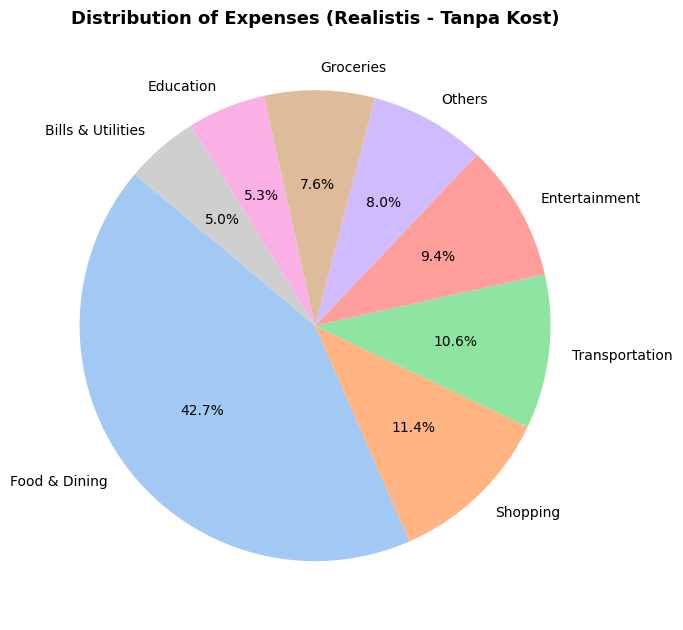

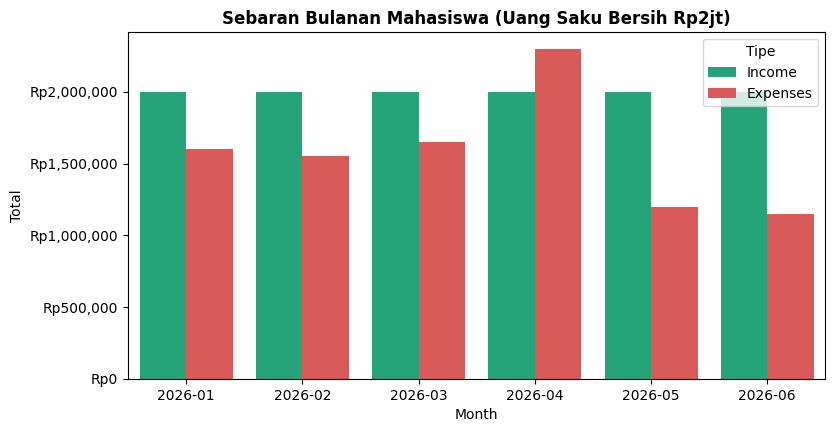

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_new = pd.read_csv('dataset_mahasiswa_realistis.csv')
df_expense = df_new[df_new['TransactionType'] == 'Expenses']

# 1. PIE CHART DISTRIBUSI BARU
plt.figure(figsize=(7, 7))
cat_data = df_expense.groupby('TransactionCategory')['Amount'].sum().sort_values(ascending=False)
cat_data.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Expenses (Realistis - Tanpa Kost)', fontsize=13, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

# 2. SEBARAN BAR CHART MONTHLY (Memastikan total pengeluaran bulanan tetap aman sesuai grafik sebelumnya)
plt.figure(figsize=(9, 4.5))
monthly_sum = df_new.groupby(['Month', 'TransactionType'])['Amount'].sum().unstack(fill_value=0).reset_index()
df_plot = pd.melt(monthly_sum, id_vars=['Month'], value_vars=['Income', 'Expenses'], var_name='Tipe', value_name='Total')
ax = sns.barplot(x='Month', y='Total', hue='Tipe', data=df_plot, palette=['#10B981', '#EF4444'])
plt.title('Sebaran Bulanan Mahasiswa (Uang Saku Bersih Rp2jt)', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "Rp{:,}".format(int(x))))
plt.show()

In [5]:
import pandas as pd

# 1. Load dataset mahasiswa realistis yang baru dibuat
df_transaksi = pd.read_csv('dataset_mahasiswa_realistis.csv')

# 2. Kelompokkan total pengeluaran per bulan berdasarkan kategorinya
# Ini akan mengubah data harian menjadi tabel bulanan dengan kolom-kolom kategori
df_bulanan = df_transaksi.groupby(['Month', 'TransactionCategory'])['Amount'].sum().unstack(fill_value=0).reset_index()

# 3. KORELASI JEMBATAN (Mencocokkan Kategori Aplikasi dengan Variabel Rumus Kamu)
# Kita buat kolom baru sesuai dengan variabel yang dibutuhkan oleh kode kamu:

# --- Kelompok INCOME ---
df_bulanan['Gaji'] = df_transaksi[df_transaksi['TransactionCategory'] == 'Allowance / Salary'].groupby('Month')['Amount'].sum().values
df_bulanan['Investasi'] = 0          # Set 0 dulu karena mahasiswa belum ada investasi aktif
df_bulanan['Pemasukan Lainnya'] = 0  # Set 0

# --- Kelompok NEEDS ---
df_bulanan['Bahan Pokok'] = df_bulanan['Food & Dining']  # Warteg, bubur ayam, kantin masuk makanan pokok
df_bulanan['Protein & Gizi Tambahan'] = 0
df_bulanan['Tempat Tinggal'] = 0                          # 0 karena tinggal sama ortu (bebas kos)
df_bulanan['Sandang'] = 0
df_bulanan['Pajak'] = 0
df_bulanan['Asuransi'] = 0

# Tambahan Kebutuhan Wajib Mahasiswa (Kita masukkan ke Kebutuhan Utama/Bahan Pokok)
# Gabungkan biaya bensin/transport, paket data, dan fotokopi kuliah ke dalam 'Bahan Pokok' / Needs
df_bulanan['Bahan Pokok'] = (
    df_bulanan['Bahan Pokok'] +
    df_bulanan.get('Transportation', 0) +
    df_bulanan.get('Bills & Utilities', 0) +
    df_bulanan.get('Education', 0) +
    df_bulanan.get('Groceries', 0)
)

# --- Kelompok WANTS ---
df_bulanan['Konsumsi Praktis'] = df_bulanan.get('Shopping', 0)  # Checkout Shopee/Tokopedia
df_bulanan['Barang & Jasa Sekunder'] = 0
df_bulanan['Pengeluaran Tidak Esensial'] = df_bulanan.get('Entertainment', 0) # Bioskop, game, netflix
df_bulanan['Sosial & Budaya'] = df_bulanan.get('Others', 0)                   # Jajan cilok, kado wisuda, parkir

# --- Kelompok SAVINGS ---
# Tabungan dihitung dari sisa uang bulanan (Gaji - Total Pengeluaran Nyata)
total_pengeluaran_nyata = df_transaksi[df_transaksi['TransactionType'] == 'Expenses'].groupby('Month')['Amount'].sum().values
df_bulanan['Tabungan / Investasi'] = df_bulanan['Gaji'] - total_pengeluaran_nyata


# =========================================================================
# SEKARANG KODE KAMU SUDAH BISA BERJALAN 100% SECARA OTOMATIS:
# =========================================================================

# Kolom baru hasil kalkulasi dari kode kamu:
df_bulanan['Income'] = (
    df_bulanan['Gaji'] +
    df_bulanan['Investasi'] +
    df_bulanan['Pemasukan Lainnya']
)

df_bulanan['Needs'] = (
    df_bulanan['Bahan Pokok'] +
    df_bulanan['Protein & Gizi Tambahan'] +
    df_bulanan['Tempat Tinggal'] +
    df_bulanan['Sandang'] +
    df_bulanan['Pajak'] +
    df_bulanan['Asuransi']
)

df_bulanan['Wants'] = (
    df_bulanan['Konsumsi Praktis'] +
    df_bulanan['Barang & Jasa Sekunder'] +
    df_bulanan['Pengeluaran Tidak Esensial'] +
    df_bulanan['Sosial & Budaya']
)

df_bulanan['Savings'] = (
    df_bulanan['Tabungan / Investasi']
)

# Tampilkan hasil akhir pengelompokan variabel untuk input model ML kamu
print(df_bulanan[['Month', 'Income', 'Needs', 'Wants', 'Savings']])

TransactionCategory    Month   Income    Needs    Wants  Savings
0                    2026-01  2000000  1161829   438171   400000
1                    2026-02  2000000  1080569   469431   450000
2                    2026-03  2000000  1276507   373493   350000
3                    2026-04  2000000  1126616  1173384  -300000
4                    2026-05  2000000  1007230   192770   800000
5                    2026-06  2000000  1079590    70410   850000
